In [ ]:
!pip install textstat
!pip install -q -U google-generativeai

In [5]:
import os
import re
import time
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import textstat
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, label_binarize
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score)
import google.generativeai as genai
from google.colab import userdata, files

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

In [7]:
df = pd.read_csv('/content/FakeNewsNet.csv')
display(df.head())

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [8]:
df = df.dropna(subset=['news_url', 'source_domain'])
df.shape

(22866, 5)

In [9]:
df['type'] = df['real'].map({0: 'fake', 1: 'real'})
df = df.drop(columns=['real'])
display(df.head())

,title,news_url,source_domain,tweet_num,type
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,real
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,real
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,real
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,real
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,real


In [19]:
GOOGLE_API_KEY = userdata.get('GOOGLE_API_KEY')
genai.configure(api_key=GOOGLE_API_KEY)
model = genai.GenerativeModel('gemini-flash-latest')

def generate_synthetic_news(topic, news_type='fake', num_samples=5, generative_model=None):
    if generative_model is None:
        print("Error: No generative model provided.")
        return None

    label_map = {
        'real': 'factual',
        'fake': 'sensationalized',
        'ai_generated': 'AI-generated, but plausible (not sensationalized or obviously fake)'
    }
    prompt_label = label_map.get(news_type, 'sensationalized')
    prompt = f"Write a list of {num_samples} {prompt_label} news headlines about {topic}. No intro."

    try:
        time.sleep(1)
        response = generative_model.generate_content(prompt)
        if not response.candidates:
            return None

        headlines = [h.strip() for h in response.text.strip().split('\n') if h.strip()]
        return pd.DataFrame({
            'title': headlines[:num_samples],
            'type': news_type,
            'source_domain': 'synthetic_gemini'
        })
    except Exception as e:
        print(f"Generation error: {e}")
        return None

In [20]:
print("Attempting simple connectivity test with Gemini 2.0 Flash...")
try:
    test_response = model.generate_content("Say hello!")
    print(f"API Response: {test_response.text}")
except Exception as e:
    print(f"Test failed: {e}")

Attempting simple connectivity test with Gemini 2.0 Flash...
API Response: Hello! How can I help you today?


In [21]:
topic = 'The Future of Artificial Intelligence and Ethics'
all_ai_generated_news = []
num_batches = 10
batch_size = 200

for i in range(num_batches):
    print(f"Generating batch {i+1}/{num_batches}...")
    batch_df = generate_synthetic_news(
        topic,
        news_type='ai_generated',
        num_samples=batch_size,
        generative_model=model
    )
    if batch_df is not None:
        all_ai_generated_news.append(batch_df)
    else:
        print(f"Warning: Failed to generate batch {i+1}")

if all_ai_generated_news:
    ai_generated_news_df = pd.concat(all_ai_generated_news).reset_index(drop=True)
    display(ai_generated_news_df.head())
    print(f"Generated {len(ai_generated_news_df)} AI-generated headlines in total.")
else:
    print("Failed to generate any AI news. Exiting.")


Generating batch 1/10...
Generating batch 2/10...


ERROR:tornado.access:503 POST /v1beta/models/gemini-flash-latest:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 18142.11ms


Generating batch 3/10...
Generating batch 4/10...
Generating batch 5/10...
Generating batch 6/10...
Generating batch 7/10...
Generating batch 8/10...
Generating batch 9/10...
Generating batch 10/10...


,title,type,source_domain
0,1. New Global Framework Proposes Ethical Stand...,ai_generated,synthetic_gemini
1,2. How Small-Scale AI Models Are Reducing the ...,ai_generated,synthetic_gemini
2,3. The Legal Battle Over Training Data: Who Ow...,ai_generated,synthetic_gemini
3,"4. Addressing the ""Black Box"" Problem in Algor...",ai_generated,synthetic_gemini
4,5. Why Human-in-the-Loop Systems Remain Essent...,ai_generated,synthetic_gemini


Generated 2000 AI-generated headlines in total.


In [22]:
multi_class_df = pd.concat([df, ai_generated_news_df]).reset_index(drop=True)

label_mapping = {'fake': 0, 'real': 1, 'ai_generated': 2}
multi_class_df['label'] = multi_class_df['type'].map(label_mapping)

display(multi_class_df.head())
print(f"Combined dataset shape: {multi_class_df.shape}")
print(f"Label distribution:\n{multi_class_df['label'].value_counts()}")

,title,news_url,source_domain,tweet_num,type,label
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42.0,real,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0.0,real,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63.0,real,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20.0,real,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38.0,real,1


Combined dataset shape: (24866, 6)
Label distribution:
label
1    17371
0     5495
2     2000
Name: count, dtype: int64


In [23]:
smallest_class_count = multi_class_df['label'].value_counts().min()

df_fake = multi_class_df[multi_class_df['label'] == 0]
df_real = multi_class_df[multi_class_df['label'] == 1]
df_ai_generated = multi_class_df[multi_class_df['label'] == 2]

df_fake_undersampled = df_fake.sample(smallest_class_count, random_state=40)
df_real_undersampled = df_real.sample(smallest_class_count, random_state=40)

multi_class_df = pd.concat([df_fake_undersampled, df_real_undersampled, df_ai_generated]).reset_index(drop=True)

print(f"Balanced dataset shape: {multi_class_df.shape}")
print(f"Balanced label distribution:\n{multi_class_df['label'].value_counts()}")


Balanced dataset shape: (6000, 6)
Balanced label distribution:
label
0    2000
1    2000
2    2000
Name: count, dtype: int64


In [24]:
sid = SentimentIntensityAnalyzer()
sentiment_scores_multi = multi_class_df['title'].apply(lambda x: sid.polarity_scores(str(x)))
multi_class_df['vader_compound'] = sentiment_scores_multi.apply(lambda x: x['compound'])
multi_class_df['vader_pos'] = sentiment_scores_multi.apply(lambda x: x['pos'])
multi_class_df['vader_neg'] = sentiment_scores_multi.apply(lambda x: x['neg'])
multi_class_df['vader_neu'] = sentiment_scores_multi.apply(lambda x: x['neu'])

multi_class_df['num_exclamations'] = multi_class_df['title'].apply(lambda x: str(x).count('!'))
multi_class_df['num_questions'] = multi_class_df['title'].apply(lambda x: str(x).count('?'))
multi_class_df['num_uppercase_words'] = multi_class_df['title'].apply(lambda x: sum(1 for word in str(x).split() if word.isupper() and len(word) > 1))
multi_class_df['flesch_kincaid_grade'] = multi_class_df['title'].apply(lambda x: textstat.flesch_kincaid_grade(str(x)))

In [25]:
tfidf_multi = TfidfVectorizer(stop_words='english', max_features=5000)
X_text_multi = tfidf_multi.fit_transform(multi_class_df['title'].astype(str))

engineered_features_multi = ['vader_compound', 'vader_pos', 'vader_neg', 'vader_neu', 'num_exclamations', 'num_questions', 'num_uppercase_words', 'flesch_kincaid_grade']
X_eng_raw_multi = multi_class_df[engineered_features_multi].fillna(0).values
scaler_multi = MinMaxScaler()
X_eng_scaled_multi = scaler_multi.fit_transform(X_eng_raw_multi)

In [26]:
X_multi_combined = sp.hstack([X_text_multi, X_eng_scaled_multi])
y_multi = multi_class_df['label'].values

X_train_multi, X_test_multi, y_train_multi, y_test_multi = train_test_split(X_multi_combined, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

print(f"Multi-class preprocessing complete. X_train_multi shape: {X_train_multi.shape}")
print(f"y_train_multi value counts: {pd.Series(y_train_multi).value_counts()}")
print(f"y_test_multi value counts: {pd.Series(y_test_multi).value_counts()}")

Multi-class preprocessing complete. X_train_multi shape: (4800, 5008)
y_train_multi value counts: 2    1600
1    1600
0    1600
Name: count, dtype: int64
y_test_multi value counts: 0    400
2    400
1    400
Name: count, dtype: int64


In [27]:
multi_class_models = {
    "Decision Tree (Multi)": DecisionTreeClassifier(random_state=42),
    "Native Bayes (Multi)": MultinomialNB(),
    "K-Nearest Neighbors (Multi)": KNeighborsClassifier(n_neighbors=5),
    "Random Forest (Multi)": RandomForestClassifier(random_state=42)
}

multi_class_model_accuracies = {}
multi_class_metrics_data = []

for model_name, model in multi_class_models.items():
    model.fit(X_train_multi, y_train_multi)
    y_pred_multi = model.predict(X_test_multi)
    accuracy_multi = accuracy_score(y_test_multi, y_pred_multi)
    multi_class_model_accuracies[model_name] = accuracy_multi
    print(f"{model_name} Accuracy: {accuracy_multi:.4f}")

    report_multi = classification_report(y_test_multi, y_pred_multi, output_dict=True)
    multi_class_metrics_data.append({
        'Model': model_name,
        'Accuracy': report_multi['accuracy'],
        'Precision (Macro)': report_multi['macro avg']['precision'],
        'Recall (Macro)': report_multi['macro avg']['recall'],
        'F1-Score (Macro)': report_multi['macro avg']['f1-score']
    })

multi_class_metrics_df = pd.DataFrame(multi_class_metrics_data)
display(multi_class_metrics_df)

Decision Tree (Multi) Accuracy: 0.7608
Native Bayes (Multi) Accuracy: 0.8325
K-Nearest Neighbors (Multi) Accuracy: 0.4217
Random Forest (Multi) Accuracy: 0.8275


,Model,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Decision Tree (Multi),0.760833,0.768561,0.760833,0.762057
1,Native Bayes (Multi),0.832500,0.830207,0.832500,0.830945
2,K-Nearest Neighbors (Multi),0.421667,0.661282,0.421667,0.369571
3,Random Forest (Multi),0.827500,0.835761,0.827500,0.826162


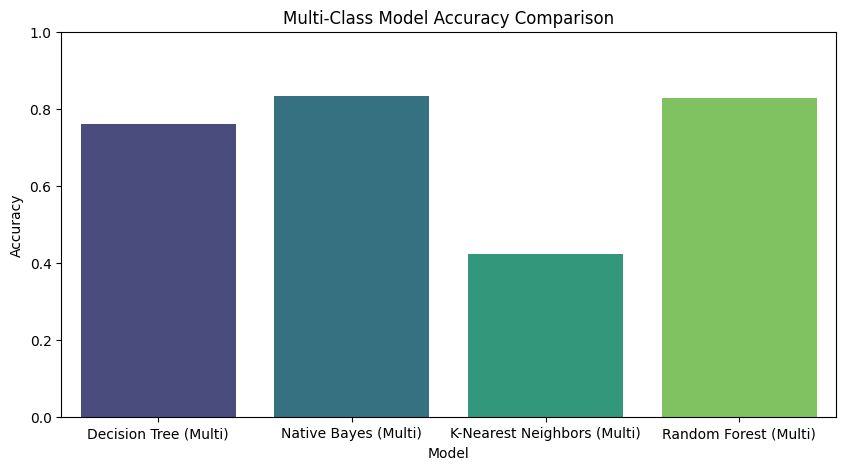

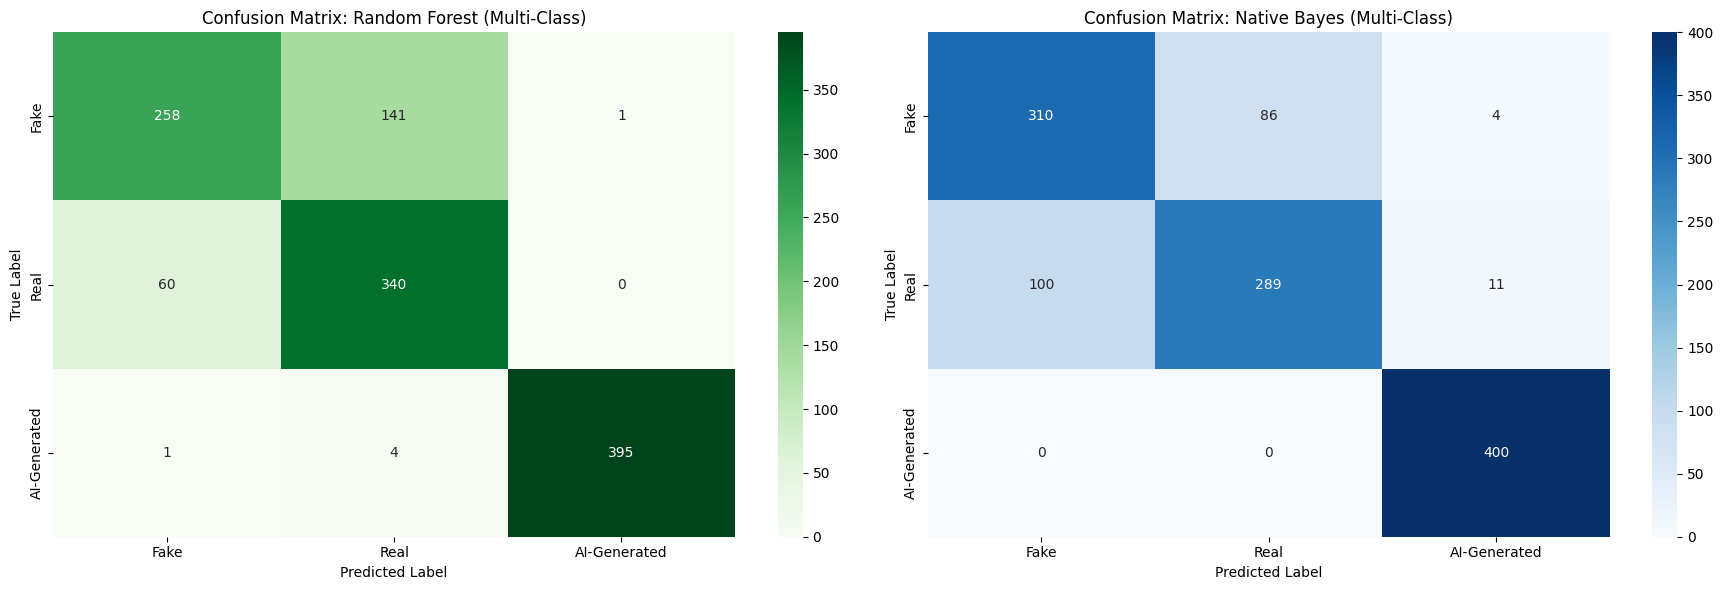

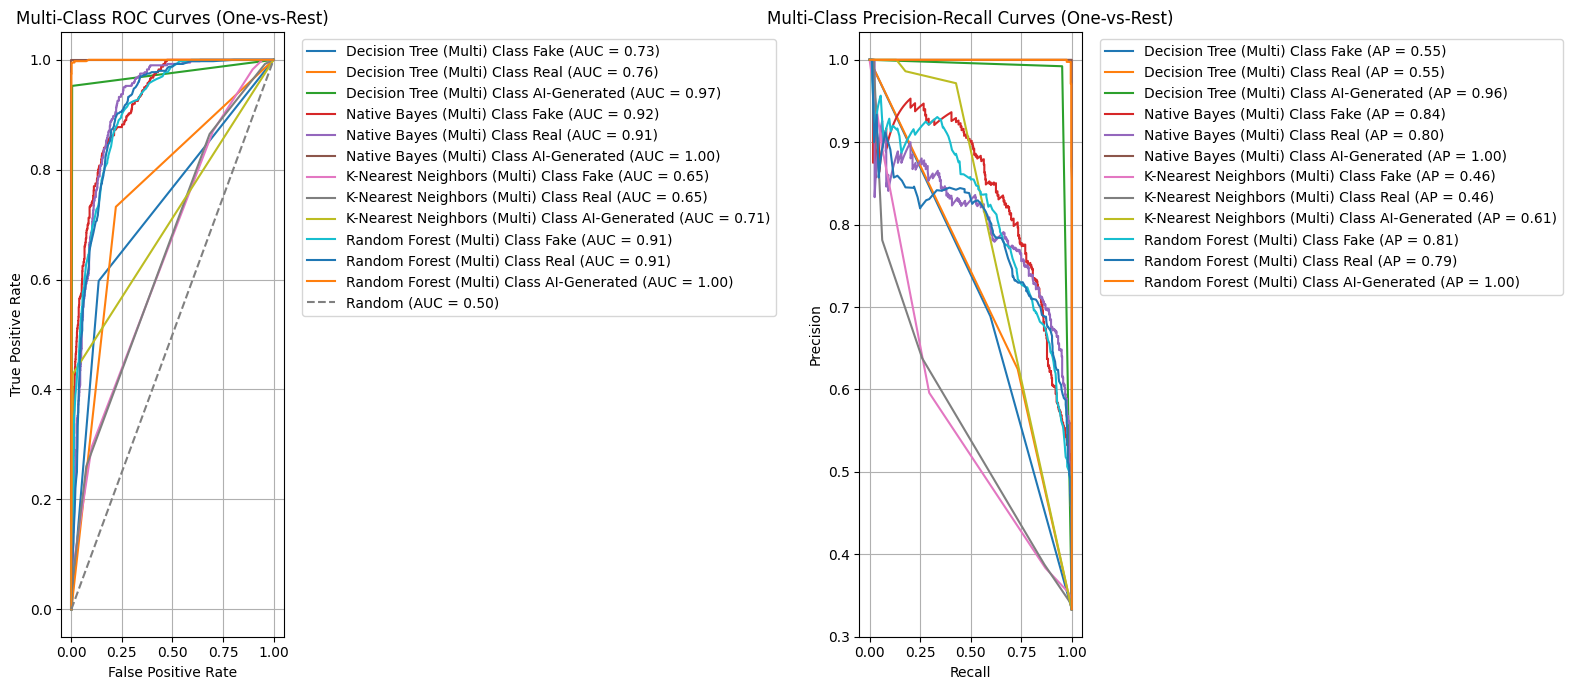

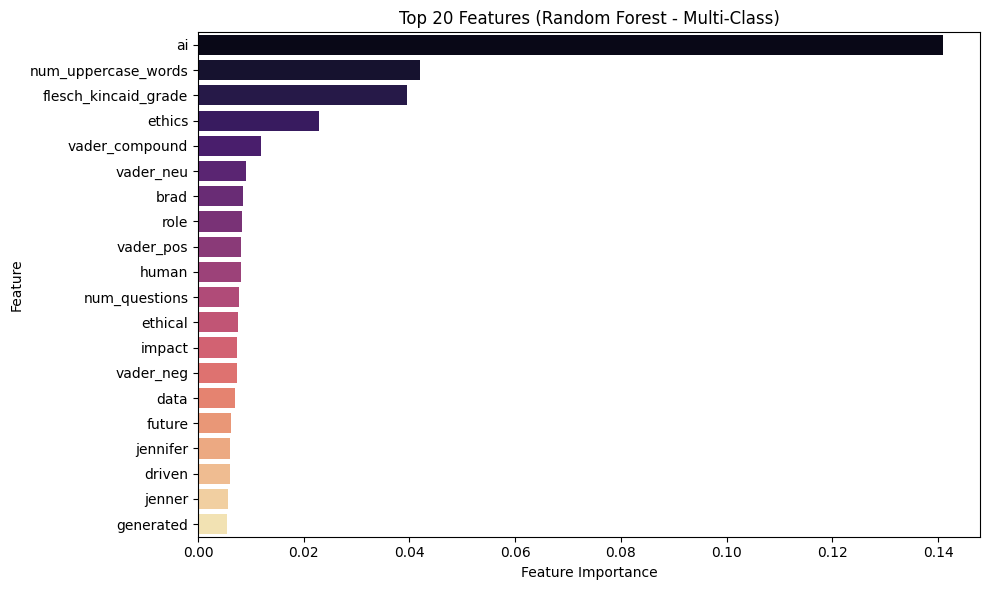

In [28]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='Accuracy', data=multi_class_metrics_df, palette='viridis', hue='Model', legend=False)
plt.title('Multi-Class Model Accuracy Comparison')
plt.ylim(0, 1)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

class_names = ['Fake', 'Real', 'AI-Generated']

rf_model_multi = multi_class_models["Random Forest (Multi)"]
y_pred_rf_multi = rf_model_multi.predict(X_test_multi)
cm_rf_multi = confusion_matrix(y_test_multi, y_pred_rf_multi)
sns.heatmap(cm_rf_multi, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names, ax=ax[0])
ax[0].set_title('Confusion Matrix: Random Forest (Multi-Class)')
ax[0].set_xlabel('Predicted Label')
ax[0].set_ylabel('True Label')

nb_model_multi = multi_class_models["Native Bayes (Multi)"]
y_pred_nb_multi = nb_model_multi.predict(X_test_multi)
cm_nb_multi = confusion_matrix(y_test_multi, y_pred_nb_multi)
sns.heatmap(cm_nb_multi, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, ax=ax[1])
ax[1].set_title('Confusion Matrix: Native Bayes (Multi-Class)')
ax[1].set_xlabel('Predicted Label')
ax[1].set_ylabel('True Label')
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 7))

y_test_binarized = label_binarize(y_test_multi, classes=[0, 1, 2])
n_classes = y_test_binarized.shape[1]

plt.subplot(1, 2, 1)
for name, model_multi in multi_class_models.items():
    if hasattr(model_multi, "predict_proba"):
        y_probs_multi = model_multi.predict_proba(X_test_multi)

        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_probs_multi[:, i])
            plt.plot(fpr, tpr, label=f'{name} Class {class_names[i]} (AUC = {auc(fpr, tpr):.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random (AUC = 0.50)')
plt.title('Multi-Class ROC Curves (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

plt.subplot(1, 2, 2)
for name, model_multi in multi_class_models.items():
    if hasattr(model_multi, "predict_proba"):
        y_probs_multi = model_multi.predict_proba(X_test_multi)

        for i in range(n_classes):
            precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_probs_multi[:, i])
            plt.plot(recall, precision, label=f'{name} Class {class_names[i]} (AP = {average_precision_score(y_test_binarized[:, i], y_probs_multi[:, i]):.2f})')
plt.title('Multi-Class Precision-Recall Curves (One-vs-Rest)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

text_features_multi = tfidf_multi.get_feature_names_out()
all_feat_names = np.concatenate([text_features_multi, engineered_features_multi])

rf_model_multi = multi_class_models["Random Forest (Multi)"]
feat_imp_multi = pd.DataFrame({'Feature': all_feat_names, 'Importance': rf_model_multi.feature_importances_})
top_20_multi = feat_imp_multi.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=top_20_multi, palette='magma', hue='Feature', legend=False)
plt.title('Top 20 Features (Random Forest - Multi-Class)')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()